## __Phase 4b: Baseline comparison (PHMM Forward vs. Nearest-Neighbor)__

Compares the PHMM Forward alignment against a naive nearest-neighbor baseline: for each RF signal, the AIS candidate whose closest point is nearest is chosen as the match. The nearest-neighbor baseline is run with four distance metrics as an ablation: plain Euclidean (lat/lon treated as Cartesian coordinates, no geodesic correction), Haversine (proper great-circle distance to the nearest AIS point), point-to-segment (perpendicular distance to the nearest AIS track leg, via a local flat-earth projection, so an RF signal landing between two AIS fixes isn't penalized for missing both), and time-weighted (the point-to-segment distance combined with an interpolated time gap — the AIS timestamp is interpolated along the leg using the same projection fraction as the spatial distance, so a spatially close but temporally distant AIS leg is penalized). All five variants are evaluated on the same preselected candidate pairs, both on all candidates and restricted to RF signals with more than one AIS candidate (same two views used in `04_evaluation.ipynb`).

### __Import packages__

In [1]:
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### __Load data__

In [2]:
# Select which RF bearing-error model's data to compare (must match the
# --error-model used to generate/run the upstream scripts)
ERROR_MODEL = "uniform"  # "uniform" or "gaussian"

# "uniform" keeps the original flat layout for backward compatibility;
# other error models live in their own subfolder under data/processed
DATA_DIR = (
    "../../AIS_RF_matching/data/processed" if ERROR_MODEL == "uniform"
    else f"../../AIS_RF_matching/data/processed/{ERROR_MODEL}"
)

# (display name, results file, score column, "max"/"min", checkpoint file)
MODELS = [
    ("PHMM Forward", "AIS_RF_forward_scores_data.pkl",
     "normalized_forward_score", "max", "AIS_RF_forward_scores_checkpoint.pkl"),
    ("NN Euclidean", "AIS_RF_nn_baseline_euclidean_scores_data.pkl",
     "nn_distance", "min", "AIS_RF_nn_baseline_euclidean_scores_checkpoint.pkl"),
    ("NN Haversine", "AIS_RF_nn_baseline_haversine_scores_data.pkl",
     "nn_distance", "min", "AIS_RF_nn_baseline_haversine_scores_checkpoint.pkl"),
    ("NN Segment", "AIS_RF_nn_baseline_segment_scores_data.pkl",
     "nn_distance", "min", "AIS_RF_nn_baseline_segment_scores_checkpoint.pkl"),
    ("NN Time-weighted", "AIS_RF_nn_baseline_time_weighted_scores_data.pkl",
     "nn_distance", "min", "AIS_RF_nn_baseline_time_weighted_scores_checkpoint.pkl"),
]

df_preselection = pd.read_pickle(f"{DATA_DIR}/AIS_RF_preselection_data.pkl")
results = {
    name: pd.read_pickle(f"{DATA_DIR}/{results_file}")
    for name, results_file, _, _, _ in MODELS
}

### __Helper functions__

In [3]:
from scripts.evaluation.metrics import (
    get_best_alignments,
    compute_confusion_counts,
    calculate_metrics,
)

In [4]:
def evaluate_models(preselection_subset):
    """
    Compute precision/recall/F1/accuracy for every model in MODELS on a
    given subset of preselected candidate pairs

    Args:
        preselection_subset (pd.DataFrame): Candidate AIS-RF pairs (either
            the full preselection, or restricted to multimatch RF signals)

    Returns:
        pd.DataFrame: One row of metrics per model
    """
    metrics = {}
    for name, _, score_col, mode, _ in MODELS:
        merged = preselection_subset.merge(
            results[name],
            on=["RF_track_id", "RF_signal_id", "AIS_track_id", "is_true_match"],
            how="inner",
        )
        chosen = get_best_alignments(merged, score_col, mode=mode)
        metrics[name] = calculate_metrics(chosen)
    return pd.DataFrame(metrics).T

### __All candidate pairs (before restricting to multimatch)__

In [5]:
comparison_all = evaluate_models(df_preselection)

print("Candidate pairs evaluated (all RF signals):", len(df_preselection))
comparison_all

Candidate pairs evaluated (all RF signals): 27136


,precision,recall,f1_score,accuracy,TP,FP,FN,TN
PHMM Forward,0.8913,0.8913,0.8913,0.8632,15225.0,1856.0,1856.0,8199.0
NN Euclidean,0.8268,0.8268,0.8268,0.7819,14122.0,2959.0,2959.0,7096.0
NN Haversine,0.8264,0.8264,0.8264,0.7814,14115.0,2966.0,2966.0,7089.0
NN Segment,0.8258,0.8258,0.8258,0.7807,14106.0,2975.0,2975.0,7080.0
NN Time-weighted,0.9293,0.9293,0.9293,0.9110,15873.0,1208.0,1208.0,8847.0


### __Restrict to RF signals with multiple AIS candidates__
RF signals with only their own AIS track as a candidate are trivially correct for any scoring method, so they are excluded here (same filtering as `04_evaluation.ipynb`).

In [6]:
df_preselection_multimatch = df_preselection.groupby(
    ["RF_track_id", "RF_signal_id"]).filter(
        lambda x: x["AIS_track_id"].count() > 1).reset_index(drop=True)

comparison_multimatch = evaluate_models(df_preselection_multimatch)

print("Candidate pairs evaluated (multimatch RF signals):", len(df_preselection_multimatch))
comparison_multimatch

Candidate pairs evaluated (multimatch RF signals): 16151


,precision,recall,f1_score,accuracy,TP,FP,FN,TN
PHMM Forward,0.6955,0.6955,0.6955,0.7702,4240.0,1856.0,1856.0,8199.0
NN Euclidean,0.5146,0.5146,0.5146,0.6336,3137.0,2959.0,2959.0,7096.0
NN Haversine,0.5135,0.5135,0.5135,0.6327,3130.0,2966.0,2966.0,7089.0
NN Segment,0.5120,0.5120,0.5120,0.6316,3121.0,2975.0,2975.0,7080.0
NN Time-weighted,0.8018,0.8018,0.8018,0.8504,4888.0,1208.0,1208.0,8847.0


### __Runtime comparison__
Average wall-clock time per AIS-RF candidate pair, taken from each model's checkpoint file (recorded during the actual scoring runs).

In [7]:
def avg_time_per_pair(checkpoint_path):
    """
    Average processing time per AIS-RF candidate pair from a checkpoint file

    Args:
        checkpoint_path (str): Path to a checkpoint file written by either
            `compute_forward_score_parallel` or `compute_nn_score_parallel`

    Returns:
        float: Average seconds spent per AIS-RF candidate pair
    """
    total_time, total_pairs = 0.0, 0
    with open(checkpoint_path, "rb") as file:
        while True:
            try:
                _, result, time_iter = pickle.load(file)
            except EOFError:
                break
            total_time += time_iter
            total_pairs += len(result)
    return total_time / total_pairs


runtime_comparison = pd.DataFrame({
    "avg_seconds_per_pair": {
        name: avg_time_per_pair(f"{DATA_DIR}/{checkpoint_file}")
        for name, _, _, _, checkpoint_file in MODELS
    }
})
runtime_comparison

,avg_seconds_per_pair
PHMM Forward,1.267612
NN Euclidean,0.000335
NN Haversine,0.001376
NN Segment,0.013979
NN Time-weighted,0.026639


### __Metrics chart__

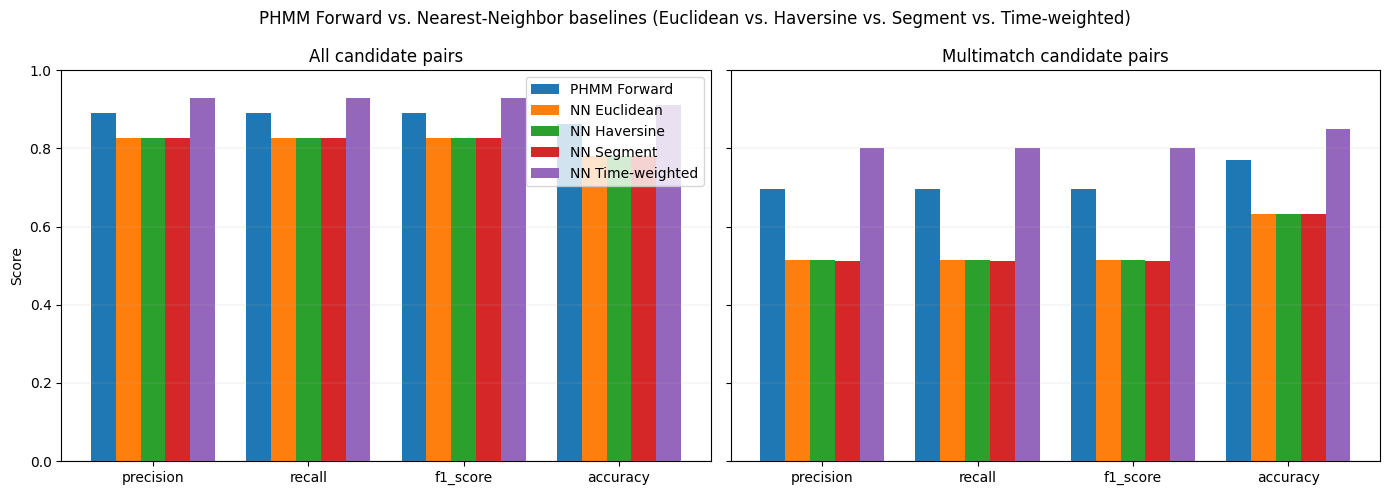

In [8]:
metric_cols = ["precision", "recall", "f1_score", "accuracy"]
x = np.arange(len(metric_cols))
n_models = len(MODELS)
width = 0.8 / n_models

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, comparison, title in zip(
    axes, [comparison_all, comparison_multimatch], ["All candidate pairs", "Multimatch candidate pairs"]
):
    for i, (name, _, _, _, _) in enumerate(MODELS):
        offset = (i - (n_models - 1) / 2) * width
        ax.bar(x + offset, comparison.loc[name, metric_cols], width, label=name)

    ax.set_xticks(x)
    ax.set_xticklabels(metric_cols)
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.grid(True, axis="y", linewidth=0.15)

axes[0].set_ylabel("Score")
axes[0].legend()
fig.suptitle("PHMM Forward vs. Nearest-Neighbor baselines (Euclidean vs. Haversine vs. Segment vs. Time-weighted)")
plt.tight_layout()
plt.show()

### __Ranking metrics (Phase 1): Recall@k, MRR, stratified by candidate-set size__

Extends the top-1 precision/recall/F1/accuracy comparison above with ranking-quality metrics for every method: Recall@k (is the true track within the top-k scored candidates), Mean Reciprocal Rank, and both broken down by how many candidates survived prefiltering.

In [9]:
from scripts.evaluation.metrics import (
    summarize_ranking,
    stratified_ranking_metrics,
    mcnemar_test,
    bootstrap_ci,
)

In [10]:
def evaluate_ranking_models(preselection_subset, ks=(1, 3, 5)):
    """
    Recall@k, MRR and their candidate-set-size stratification for
    every model in MODELS, on a given subset of preselected candidate
    pairs

    Args:
        preselection_subset (pd.DataFrame): Candidate AIS-RF pairs
            (either the full preselection, or restricted to multimatch
            RF signals)
        ks (tuple[int]): Recall@k cutoffs to report

    Returns:
        tuple[pd.DataFrame, dict[str, pd.DataFrame]]: a long-form table
        with one row per (model, candidate-count bucket) — columns
        model, bucket, n_points, recall@<k> for each k, mrr — and a
        dict mapping model name to its per-RF-point ranking summary
        (from summarize_ranking), reused below for the margin plots
        and significance tests
    """
    stratified_tables = []
    summaries = {}
    for name, _, score_col, mode, _ in MODELS:
        merged = preselection_subset.merge(
            results[name],
            on=["RF_track_id", "RF_signal_id", "AIS_track_id", "is_true_match"],
            how="inner",
        )
        summary = summarize_ranking(merged, score_col, mode=mode, ks=ks)
        summaries[name] = summary

        stratified = stratified_ranking_metrics(summary, ks=ks)
        stratified.insert(0, "model", name)
        stratified_tables.append(stratified)

    return pd.concat(stratified_tables, ignore_index=True), summaries

In [11]:
ranking_comparison_all, ranking_summaries_all = evaluate_ranking_models(df_preselection)

print("Candidate pairs evaluated (all RF signals):", len(df_preselection))
ranking_comparison_all

Candidate pairs evaluated (all RF signals): 27136


,model,bucket,n_points,recall@1,recall@3,recall@5,mrr
0,PHMM Forward,all,17081,0.891341,0.995082,1.000000,0.941109
1,PHMM Forward,1,10985,1.000000,1.000000,1.000000,1.000000
2,PHMM Forward,2-4,5778,0.709934,0.991866,1.000000,0.844915
3,PHMM Forward,5-9,318,0.433962,0.883648,1.000000,0.654612
4,NN Euclidean,all,17081,0.826767,0.985364,0.999356,0.903611
5,NN Euclidean,1,10985,1.000000,1.000000,1.000000,1.000000
6,NN Euclidean,2-4,5778,0.526653,0.974386,1.000000,0.740943
7,NN Euclidean,5-9,318,0.295597,0.679245,0.965409,0.529593
8,NN Haversine,all,17081,0.826357,0.985774,0.999297,0.903526
9,NN Haversine,1,10985,1.000000,1.000000,1.000000,1.000000


In [12]:
ranking_comparison_multi, ranking_summaries_multi = evaluate_ranking_models(df_preselection_multimatch)

print("Candidate pairs evaluated (multimatch RF signals):", len(df_preselection_multimatch))
ranking_comparison_multi

Candidate pairs evaluated (multimatch RF signals): 16151


,model,bucket,n_points,recall@1,recall@3,recall@5,mrr
0,PHMM Forward,all,6096,0.695538,0.986220,1.000000,0.834987
1,PHMM Forward,2-4,5778,0.709934,0.991866,1.000000,0.844915
2,PHMM Forward,5-9,318,0.433962,0.883648,1.000000,0.654612
3,NN Euclidean,all,6096,0.514600,0.958990,0.998196,0.729918
4,NN Euclidean,2-4,5778,0.526653,0.974386,1.000000,0.740943
5,NN Euclidean,5-9,318,0.295597,0.679245,0.965409,0.529593
6,NN Haversine,all,6096,0.513451,0.960138,0.998031,0.729680
7,NN Haversine,2-4,5778,0.524922,0.974732,1.000000,0.740423
8,NN Haversine,5-9,318,0.305031,0.694969,0.962264,0.534468
9,NN Segment,all,6096,0.511975,0.960302,0.997867,0.728840


#### _Score margin per method: correct vs incorrect top-1 picks_

Diagnostic (not a final metric): best-minus-second-best score for each RF point, oriented so a larger value always means a more confident top-1 pick regardless of whether the method's raw score is max- or min-is-better. Only defined for RF points with 2+ candidates, so this uses the multimatch ranking summaries. Needed as input for the Phase 2 open-set threshold analysis.

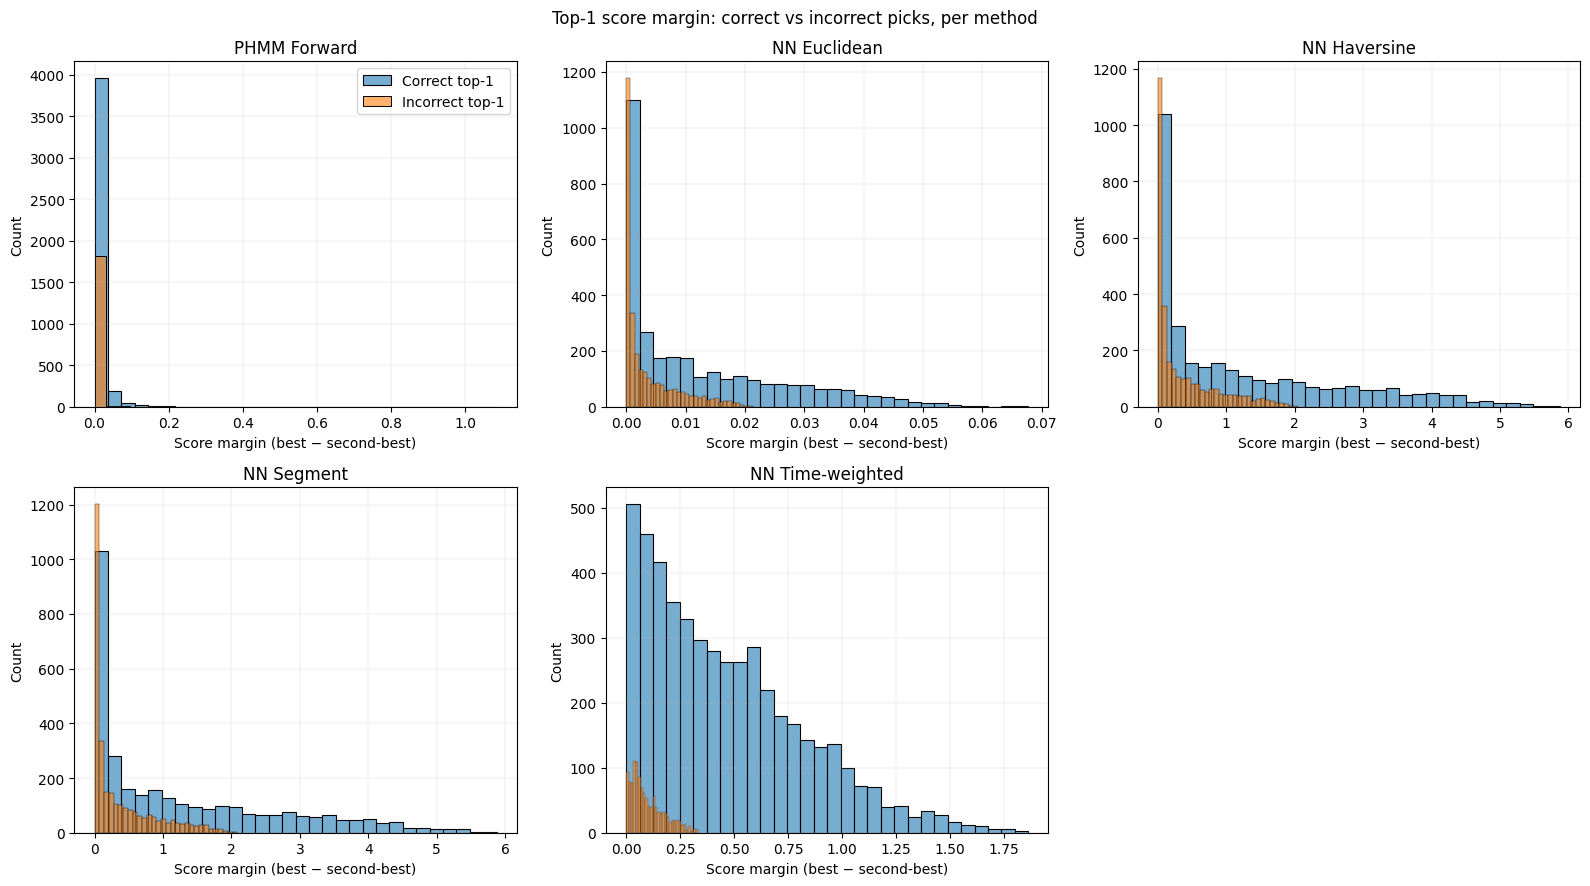

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (name, _, _, _, _) in zip(axes, MODELS):
    summary = ranking_summaries_multi[name].dropna(subset=["margin"]).copy()
    summary["top1_correct"] = summary["rank_of_true"] == 1

    sns.histplot(
        summary.loc[summary["top1_correct"], "margin"],
        bins=30, alpha=0.6, label="Correct top-1", color="tab:blue", ax=ax,
    )
    sns.histplot(
        summary.loc[~summary["top1_correct"], "margin"],
        bins=30, alpha=0.6, label="Incorrect top-1", color="tab:orange", ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Score margin (best − second-best)")
    ax.grid(True, linewidth=0.15)

axes[0].legend()
for ax in axes[len(MODELS):]:
    ax.axis("off")

fig.suptitle("Top-1 score margin: correct vs incorrect picks, per method")
plt.tight_layout()
plt.show()

### __Statistical comparison between methods__

Computed on the all-candidate-pairs view (`ranking_summaries_all`). McNemar's test is paired on each RF point's binary top-1 correct/incorrect outcome, comparing PHMM Forward against each baseline in turn. Bootstrap CIs (1000 resamples of RF points, 95% interval) are reported per method for Recall@1 and MRR, to tell whether small gaps between baseline variants are actually significant or within noise.

In [14]:
HMM_NAME = "PHMM Forward"
hmm_summary = ranking_summaries_all[HMM_NAME].set_index(["RF_signal_id", "RF_track_id"])

mcnemar_rows = []
for name, _, _, _, _ in MODELS:
    if name == HMM_NAME:
        continue
    other_summary = ranking_summaries_all[name].set_index(["RF_signal_id", "RF_track_id"])
    aligned = hmm_summary[["hit@1"]].join(
        other_summary[["hit@1"]], how="inner", lsuffix="_hmm", rsuffix="_other"
    )
    result = mcnemar_test(aligned["hit@1_hmm"], aligned["hit@1_other"])
    result["comparison"] = f"{HMM_NAME} vs {name}"
    result["n_points"] = len(aligned)
    mcnemar_rows.append(result)

mcnemar_table = pd.DataFrame(mcnemar_rows)[
    ["comparison", "n_points", "n10", "n01", "statistic", "p_value", "method"]
]
mcnemar_table

,comparison,n_points,n10,n01,statistic,p_value,method
0,PHMM Forward vs NN Euclidean,17081,1925,822,442.083728,0.0,chi2
1,PHMM Forward vs NN Haversine,17081,1930,820,447.229455,0.0,chi2
2,PHMM Forward vs NN Segment,17081,1935,816,454.352599,0.0,chi2
3,PHMM Forward vs NN Time-weighted,17081,531,1179,244.800585,0.0,chi2


In [15]:
bootstrap_rows = []
for name, _, _, _, _ in MODELS:
    summary = ranking_summaries_all[name]
    r1_est, r1_lo, r1_hi = bootstrap_ci(summary, "hit@1", n_boot=1000, random_state=42)
    mrr_est, mrr_lo, mrr_hi = bootstrap_ci(summary, "reciprocal_rank", n_boot=1000, random_state=42)
    bootstrap_rows.append({
        "model": name,
        "recall@1": r1_est, "recall@1_ci_lo": r1_lo, "recall@1_ci_hi": r1_hi,
        "mrr": mrr_est, "mrr_ci_lo": mrr_lo, "mrr_ci_hi": mrr_hi,
    })

bootstrap_table = pd.DataFrame(bootstrap_rows)
bootstrap_table

,model,recall@1,recall@1_ci_lo,recall@1_ci_hi,mrr,mrr_ci_lo,mrr_ci_hi
0,PHMM Forward,0.891341,0.886715,0.895968,0.941109,0.938576,0.943736
1,NN Euclidean,0.826767,0.821380,0.832211,0.903611,0.900585,0.906674
2,NN Haversine,0.826357,0.820735,0.831919,0.903526,0.900404,0.906674
3,NN Segment,0.825830,0.820210,0.831452,0.903226,0.900082,0.906431
4,NN Time-weighted,0.929278,0.925647,0.932966,0.963205,0.961350,0.965166


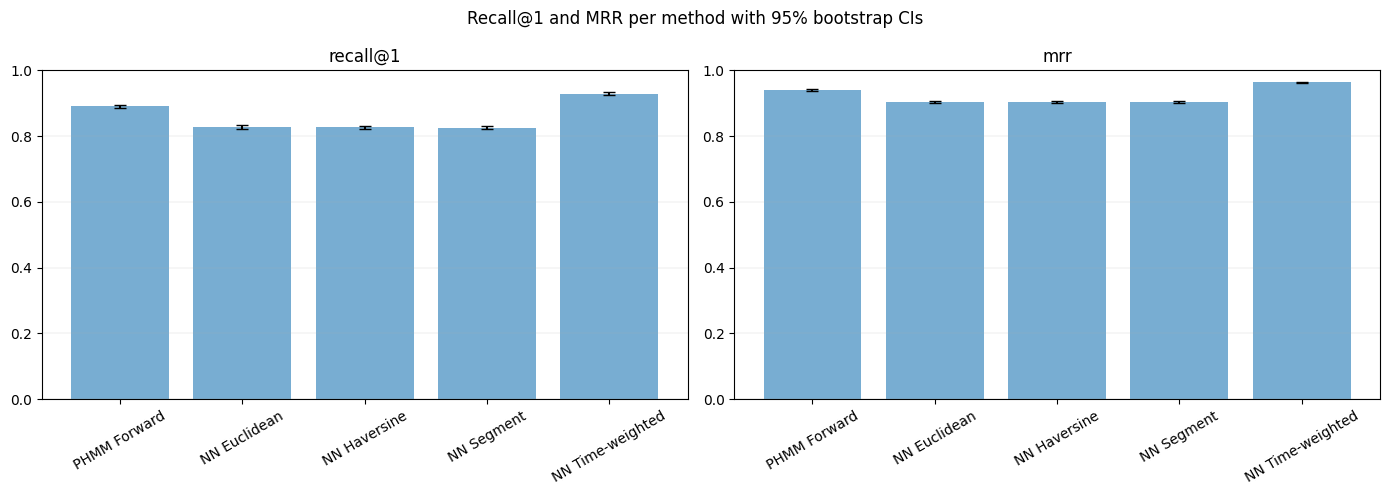

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, lo_col, hi_col in zip(
    axes,
    ["recall@1", "mrr"],
    ["recall@1_ci_lo", "mrr_ci_lo"],
    ["recall@1_ci_hi", "mrr_ci_hi"],
):
    y = bootstrap_table[metric]
    yerr = [y - bootstrap_table[lo_col], bootstrap_table[hi_col] - y]
    ax.bar(bootstrap_table["model"], y, yerr=yerr, capsize=4, color="#78add2")
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.grid(True, axis="y", linewidth=0.15)
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("Recall@1 and MRR per method with 95% bootstrap CIs")
plt.tight_layout()
plt.show()